<a href="https://colab.research.google.com/github/Sosswood/Machine-Learning/blob/main/Group_Project_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
x,y = make_blobs(n_samples=300, n_features=2, centers=5, random_state=42)
# make the blobs: y contains the cluster IDs, but we
                          # will not use them; that's what we want to predict
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(x)

### Load Data for Clustering
First, let's load the `AB_NYC_2019_prepared_with_distance.csv` dataset into a pandas DataFrame.

In [ ]:
import pandas as pd

# Load the dataset
df_nyc = pd.read_csv('/content/AB_NYC_2019_prepared_with_distance.csv')

# Display the first few rows and information to understand the data
display(df_nyc.head())
print(df_nyc.info())

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,distance_times_square_km
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,12.337915
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,0.508366
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365,6.757250
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,8.387046
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,5.701504


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48884 entries, 0 to 48883
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48884 non-null  object 
 1   neighbourhood                   48884 non-null  object 
 2   latitude                        48884 non-null  float64
 3   longitude                       48884 non-null  float64
 4   room_type                       48884 non-null  object 
 5   price                           48884 non-null  int64  
 6   minimum_nights                  48884 non-null  int64  
 7   number_of_reviews               48884 non-null  int64  
 8   last_review                     38833 non-null  object 
 9   reviews_per_month               48884 non-null  float64
 10  calculated_host_listings_count  48884 non-null  int64  
 11  availability_365                48884 non-null  int64  
 12  distance_times_square_km        

### Data Preprocessing for Clustering
We need to select the numerical features relevant for clustering. Categorical features or identifiers should be excluded. Also, it's good practice to scale the numerical features before applying KMeans, as it is a distance-based algorithm.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select relevant numerical features for clustering
# Exclude 'id', 'name', 'host_id', 'host_name', 'last_review', 'reviews_per_month'
# 'neighbourhood_group', 'neighbourhood' might be interesting but are categorical and require one-hot encoding
# For simplicity, let's start with readily available numerical columns.
# Also, drop columns that are not useful or have many missing values for clustering

# Identify numerical columns (excluding potential identifiers or date-like columns)
features = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
            'calculated_host_listings_count', 'availability_365', 'price', 'distance_times_square_km']

# Create a copy of the dataframe with selected features
X = df_nyc[features].copy()

# Handle potential missing values (if any) - fill with mean for simplicity
# In a real scenario, more sophisticated imputation might be needed
X.fillna(X.mean(), inplace=True)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier inspection (optional)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
display(X_scaled_df.head())

,latitude,longitude,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,price,distance_times_square_km
0,-1.493872,-0.437504,-0.293969,-0.320353,-0.034732,1.916192,-0.015635,1.178703
1,0.452352,-0.684480,-0.293969,0.487712,-0.156107,1.840219,0.300810,-1.487086
2,1.468284,0.222616,-0.196465,-0.522369,-0.186450,1.916192,-0.011471,-0.078900
3,-0.803442,-0.164313,-0.293969,5.538118,-0.186450,0.617056,-0.265460,0.288375
4,1.275551,0.177337,0.144799,-0.320353,-0.186450,-0.856818,-0.302934,-0.316812


### Apply KMeans Clustering
Now, let's apply KMeans clustering. We need to decide on the number of clusters (`k`). For demonstration, I will choose an arbitrary `k=5`. In a real-world scenario, you would typically use methods like the Elbow Method or Silhouette Score to determine an optimal `k`.

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

k = 5 # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
y_pred = kmeans.fit_predict(X_scaled)

# Add the cluster labels back to the original DataFrame (or the feature DataFrame)
df_nyc['cluster'] = y_pred

# Display the first few rows with the new cluster assignments
display(df_nyc.head())

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,distance_times_square_km,cluster
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,12.337915,1
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,0.508366,0
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365,6.757250,0
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,8.387046,3
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,5.701504,2


### Visualize the Clusters
Let's visualize the clusters, for example, using latitude and longitude, to see how they are spatially distributed.

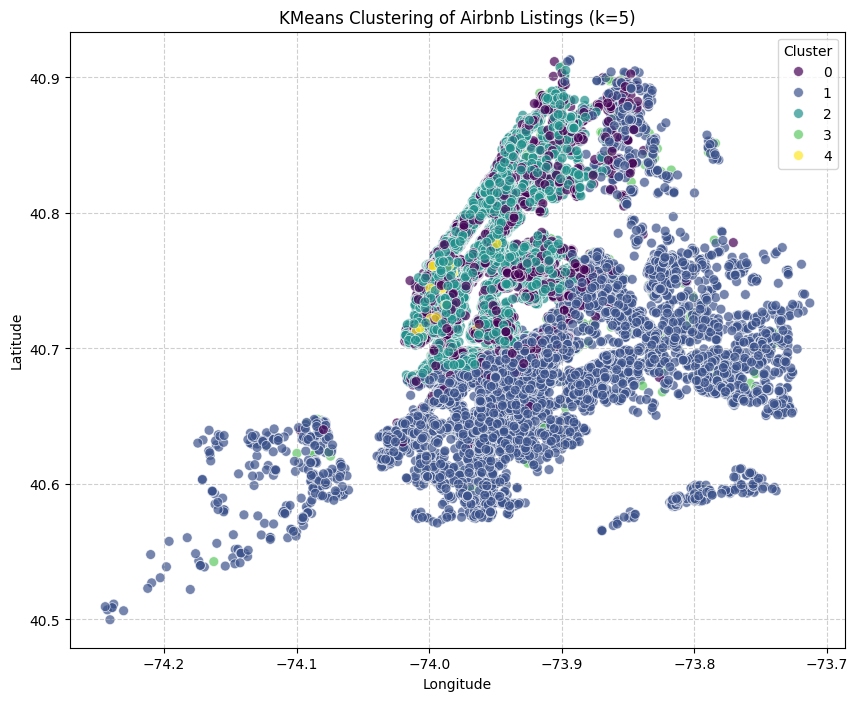

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', hue='cluster', data=df_nyc, palette='viridis', s=50, alpha=0.7)
plt.title('KMeans Clustering of Airbnb Listings (k=5)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Analyze Cluster Characteristics
We can also look at the characteristics of each cluster by examining the mean values of the features within each cluster.

In [ ]:
cluster_summary = df_nyc.groupby('cluster')[features].mean()
display(cluster_summary)

,latitude,longitude,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,price,distance_times_square_km
cluster,,,,,,,,
0,40.751467,-73.962039,17.749466,14.187085,12.795140,294.605917,248.413432,4.951937
1,40.681159,-73.927396,4.570627,16.231246,2.183282,103.905522,98.479185,11.549961
2,40.753975,-73.965075,4.548004,11.290227,1.663088,25.743326,152.540239,4.865874
3,40.729499,-73.950338,2.894906,154.755269,2.043326,182.936183,126.144321,7.236837
4,40.729629,-73.996995,21.150268,2.343470,287.572451,281.703041,273.928444,3.789648


### Determine Optimal Number of Clusters (Elbow Method)
To find a more appropriate number of clusters, we can use the Elbow Method. This involves plotting the inertia (sum of squared distances of samples to their closest cluster center) for a range of `k` values and looking for an 'elbow' point where the rate of decrease dramatically slows down.

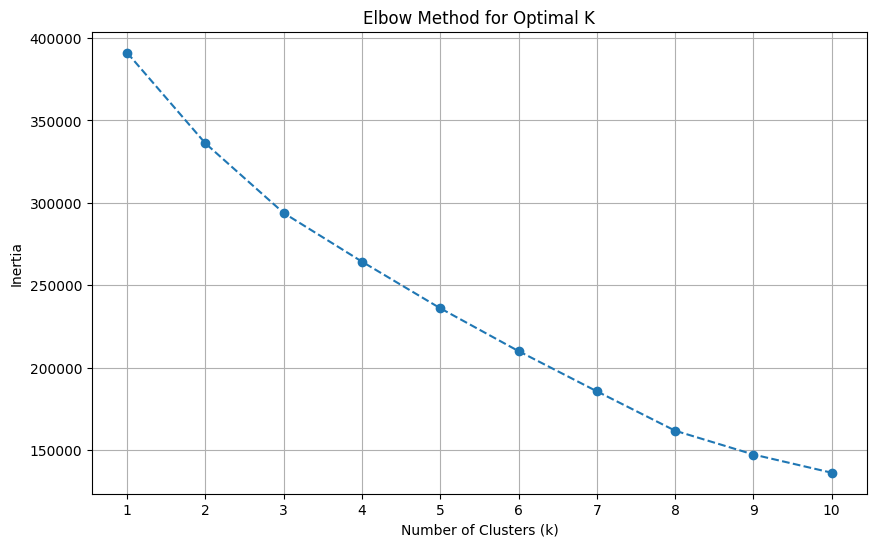

In [ ]:
inertia = []
k_range = range(1, 11) # Test k from 1 to 10

for k_val in k_range:
    kmeans_model = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    kmeans_model.fit(X_scaled)
    inertia.append(kmeans_model.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

### Re-run KMeans with Optimal K (k=3)
Based on the elbow plot, `k=3` appears to be a reasonable choice for the number of clusters. Let's re-run the KMeans algorithm with this updated `k` value.

In [ ]:
k_optimal = 3 # Chosen from the elbow plot
kmeans_optimal = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
y_pred_optimal = kmeans_optimal.fit_predict(X_scaled)

# Update the 'cluster' column in the original DataFrame with the new optimal clusters
df_nyc['cluster_optimal'] = y_pred_optimal

# Display the first few rows with the new cluster assignments
display(df_nyc.head())

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,distance_times_square_km,cluster,cluster_optimal
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,12.337915,1,1
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,0.508366,0,0
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365,6.757250,0,0
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,8.387046,3,1
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,5.701504,2,0


### Visualize Price vs. Distance_times_square_km for Optimal Clusters
Let's visualize how 'price' and 'distance_times_square_km' correlate within these newly formed `k=3` clusters.

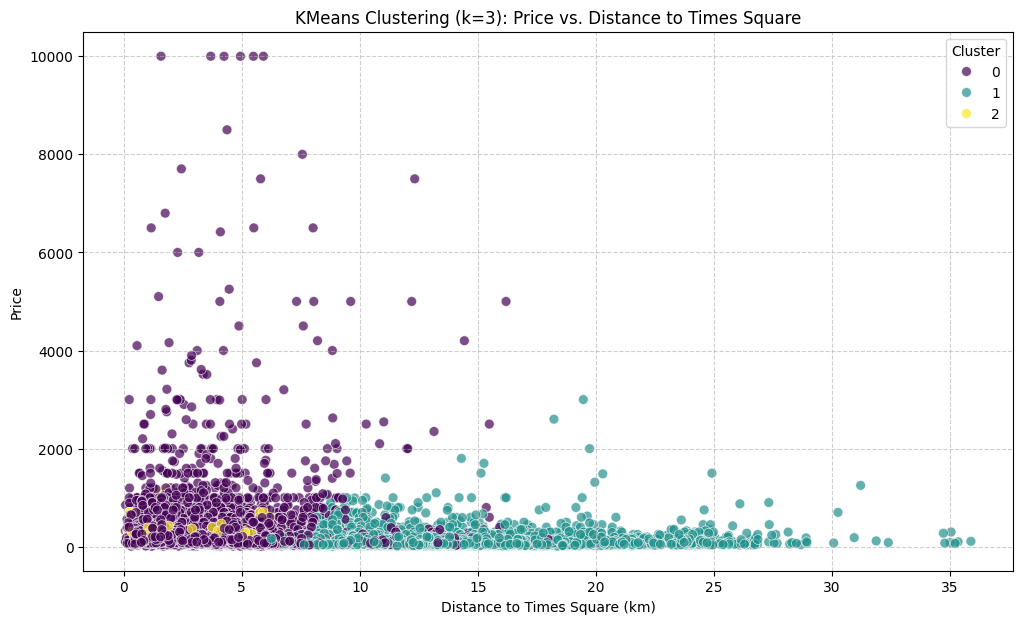

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='distance_times_square_km', y='price', hue='cluster_optimal', data=df_nyc, palette='viridis', s=50, alpha=0.7)
plt.title(f'KMeans Clustering (k={k_optimal}): Price vs. Distance to Times Square')
plt.xlabel('Distance to Times Square (km)')
plt.ylabel('Price')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Analyze Cluster Characteristics with Optimal K
Now, let's examine the mean values of the features, specifically 'price' and 'distance_times_square_km', for the `k=3` clusters to identify any correlations.

In [ ]:
cluster_summary_optimal = df_nyc.groupby('cluster_optimal')[['price', 'distance_times_square_km']].mean()
display(cluster_summary_optimal)

# You can also get a more comprehensive summary:
# cluster_summary_full = df_nyc.groupby('cluster_optimal')[features].mean()
# display(cluster_summary_full)

,price,distance_times_square_km
cluster_optimal,,
0,183.230393,4.574135
1,103.363368,11.009631
2,276.084806,3.794696


/tmp/ipykernel_1980/4239441585.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary_optimal.index, y='price', data=cluster_summary_optimal, ax=axes[0], palette='viridis')
/tmp/ipykernel_1980/4239441585.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary_optimal.index, y='distance_times_square_km', data=cluster_summary_optimal, ax=axes[1], palette='plasma')


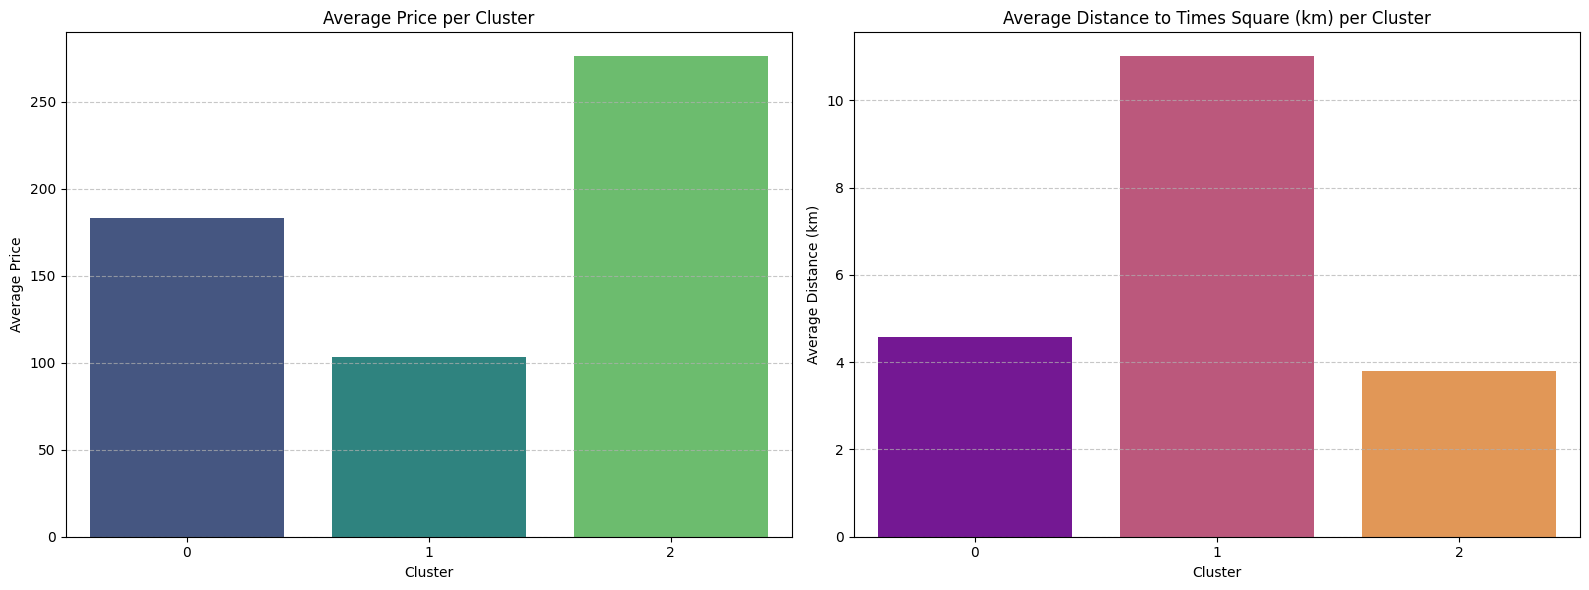

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Average Price per Cluster
sns.barplot(x=cluster_summary_optimal.index, y='price', data=cluster_summary_optimal, ax=axes[0], palette='viridis')
axes[0].set_title('Average Price per Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Average Price')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot for Average Distance to Times Square per Cluster
sns.barplot(x=cluster_summary_optimal.index, y='distance_times_square_km', data=cluster_summary_optimal, ax=axes[1], palette='plasma')
axes[1].set_title('Average Distance to Times Square (km) per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Average Distance (km)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Combined Graphical Representation of Cluster Summary
Let's visualize the `cluster_summary_optimal` data using a single grouped bar chart to compare average price and average distance for each cluster.

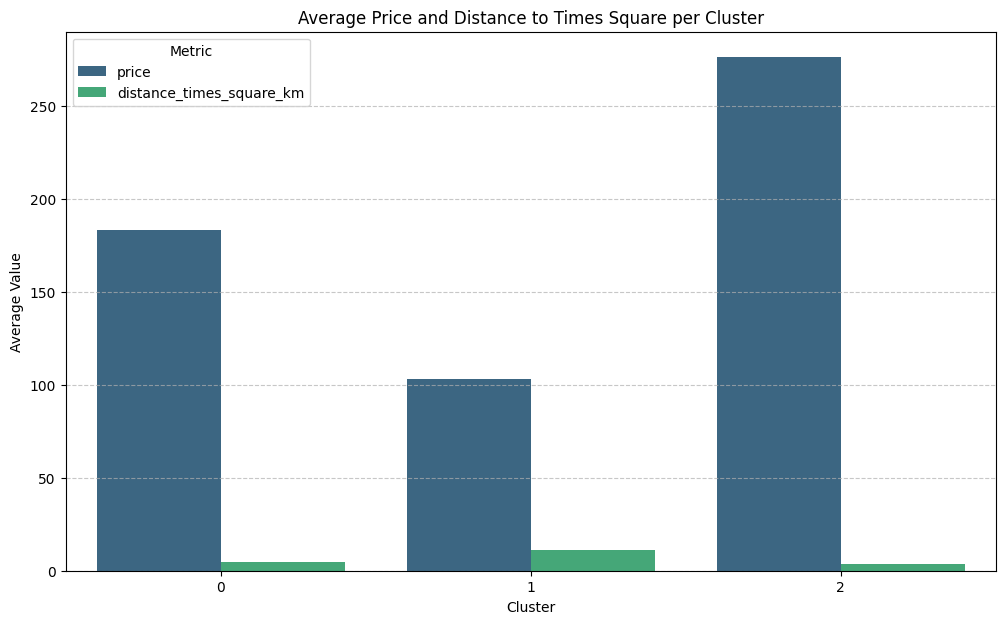

In [ ]:
# Melt the DataFrame to long format for easy plotting
cluster_summary_melted = cluster_summary_optimal.reset_index().melt(id_vars='cluster_optimal',
                                                                   value_vars=['price', 'distance_times_square_km'],
                                                                   var_name='Metric',
                                                                   value_name='Average Value')

plt.figure(figsize=(12, 7))
sns.barplot(x='cluster_optimal', y='Average Value', hue='Metric', data=cluster_summary_melted, palette='viridis')
plt.title('Average Price and Distance to Times Square per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric')
plt.show()

### Combined Line Graph Representation of Cluster Summary
Let's visualize the `cluster_summary_optimal` data using a line graph to see the trends of average price and average distance for each cluster.

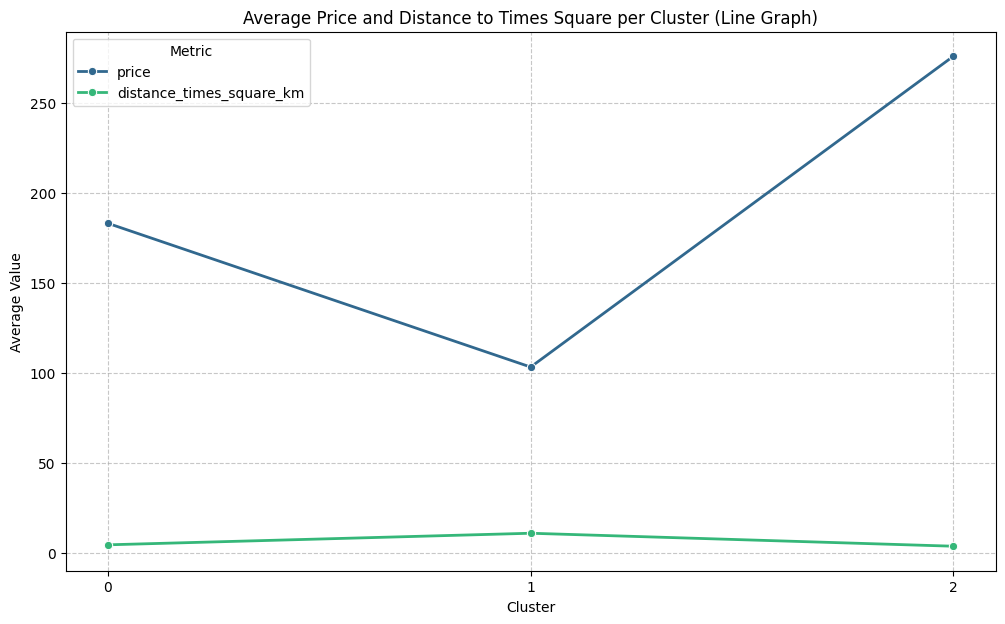

In [ ]:
plt.figure(figsize=(12, 7))
sns.lineplot(x='cluster_optimal', y='Average Value', hue='Metric', data=cluster_summary_melted, marker='o', palette='viridis', lw=2)
plt.title('Average Price and Distance to Times Square per Cluster (Line Graph)')
plt.xlabel('Cluster')
plt.ylabel('Average Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Metric')
plt.xticks(cluster_summary_melted['cluster_optimal'].unique()) # Ensure all cluster labels are shown
plt.show()

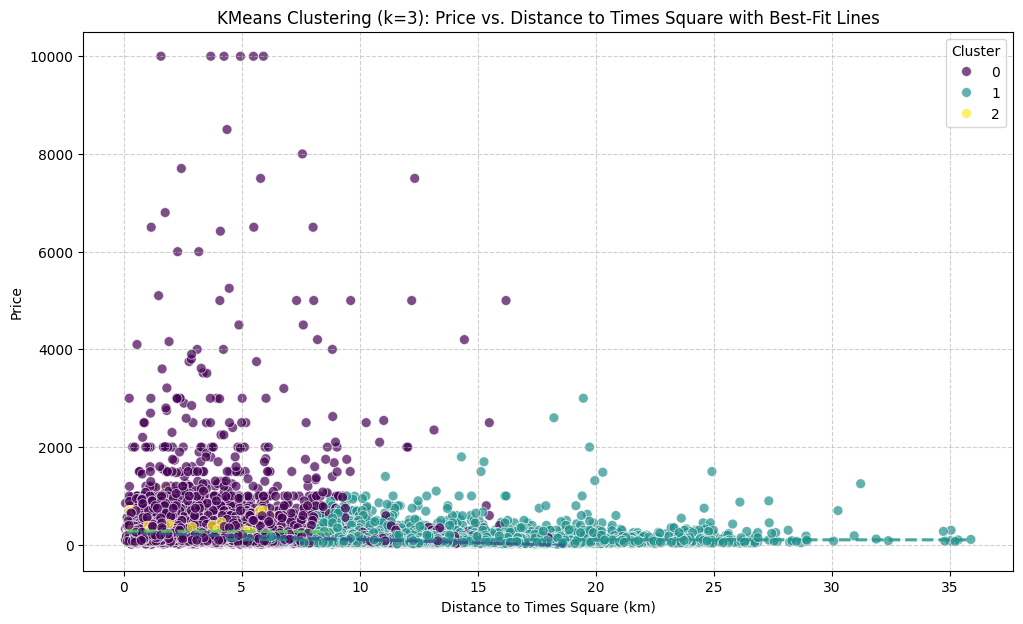

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='distance_times_square_km', y='price', hue='cluster_optimal', data=df_nyc, palette='viridis', s=50, alpha=0.7)

# Add best-fit lines for each cluster
for cluster_id in df_nyc['cluster_optimal'].unique():
    subset = df_nyc[df_nyc['cluster_optimal'] == cluster_id]
    sns.regplot(
        x='distance_times_square_km',
        y='price',
        data=subset,
        scatter=False, # Do not plot individual scattered points again
        color=sns.color_palette('viridis', n_colors=len(df_nyc['cluster_optimal'].unique()))[cluster_id], # Match color to scatter plot
        line_kws={'linestyle':'--', 'alpha':0.9, 'lw': 2.5}, # Style for the regression line, increased linewidth
        ax=plt.gca() # Plot on the current axes
    )

plt.title(f'KMeans Clustering (k={k_optimal}): Price vs. Distance to Times Square with Best-Fit Lines')
plt.xlabel('Distance to Times Square (km)')
plt.ylabel('Price')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Product Moment Correlation Coefficient (PCC)
Let's calculate the Pearson product-moment correlation coefficient between 'price' and 'distance_times_square_km' for the overall dataset to understand their linear relationship.

In [ ]:
correlation = df_nyc['price'].corr(df_nyc['distance_times_square_km'], method='pearson')
print(f"The Product Moment Correlation Coefficient between Price and Distance to Times Square is: {correlation:.4f}")

The Product Moment Correlation Coefficient between Price and Distance to Times Square is: -0.1726


### Clustering Based on Distance to Times Square
To cluster the data solely based on `distance_times_square_km`, we first need to isolate this feature and prepare it for clustering. We'll then use the Elbow Method to determine a suitable number of clusters.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Extract the 'distance_times_square_km' feature
distance_data = df_nyc[['distance_times_square_km']].copy()

# Scale the data
distance_scaler = StandardScaler()
distance_scaled = distance_scaler.fit_transform(distance_data)

# Convert back to DataFrame for easier handling if needed (optional)
distance_scaled_df = pd.DataFrame(distance_scaled, columns=['distance_times_square_km'])
display(distance_scaled_df.head())

,distance_times_square_km
0,1.178703
1,-1.487086
2,-0.078900
3,0.288375
4,-0.316812


### Elbow Method for Distance-Based Clustering
Now, let's apply the Elbow Method to find the optimal number of clusters (`k`) for the `distance_times_square_km` feature.

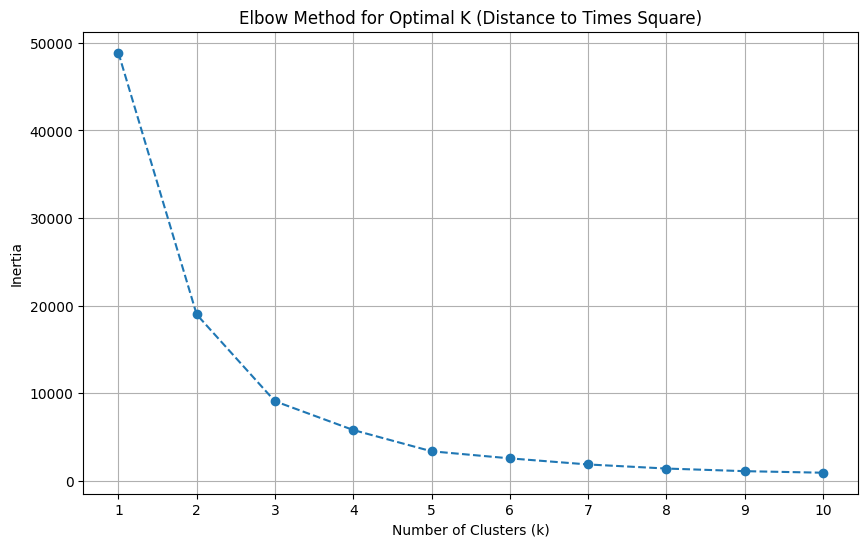

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_distance = []
k_range_distance = range(1, 11) # Test k from 1 to 10

for k_val in k_range_distance:
    kmeans_distance_model = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    kmeans_distance_model.fit(distance_scaled)
    inertia_distance.append(kmeans_distance_model.inertia_)

# Plot the elbow curve for distance clustering
plt.figure(figsize=(10, 6))
plt.plot(k_range_distance, inertia_distance, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K (Distance to Times Square)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range_distance)
plt.grid(True)
plt.show()

### Apply KMeans Clustering Based on Distance
Based on the Elbow Method, `k=3` appears to be a reasonable choice for clustering `distance_times_square_km`. Let's apply KMeans with this value and add the new cluster labels to our DataFrame.

In [ ]:
k_optimal_distance = 3 # Chosen from the elbow plot for distance
kmeans_distance_optimal = KMeans(n_clusters=k_optimal_distance, random_state=42, n_init=10)
df_nyc['distance_cluster'] = kmeans_distance_optimal.fit_predict(distance_scaled)

display(df_nyc.head())

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,distance_times_square_km,cluster,cluster_optimal,distance_cluster
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,12.337915,1,1,1
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,0.508366,0,0,0
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365,6.757250,0,0,1
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,8.387046,3,1,1
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,5.701504,2,0,0


### Analyze Distance Cluster Characteristics
Let's examine the mean `distance_times_square_km` for these new clusters to understand how they differ.

In [ ]:
distance_cluster_summary = df_nyc.groupby('distance_cluster')[['distance_times_square_km']].mean()
display(distance_cluster_summary)

,distance_times_square_km
distance_cluster,
0,3.659265
1,8.985762
2,16.197692
